# Análise de Crédito e Cobrança - Projeto em Python

Este notebook demonstra a aplicação de técnicas de análise de dados para gestão de crédito e cobrança, utilizando dados sintéticos gerados especificamente para este projeto.

## Objetivos:
- Importar e explorar os dados de clientes, transações, demonstrações financeiras, pendências e pedidos bloqueados.
- Realizar análise de aging (vencimentos) e inadimplência.
- Identificar pendências que necessitam de ajustes (abatimentos, créditos, estornos).
- Calcular indicadores financeiros e classificar clientes por risco de crédito.
- Analisar pedidos bloqueados por limite e sugerir ações.
- Gerar visualizações e relatórios para tomada de decisão.

## 1. Configuração Inicial

In [50]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizações
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%load_ext autoreload
%autoreload 2
# depois reexecute a célula que importa os módulos

# Importar módulos do projeto (assumindo que o notebook está na raiz ou adicionamos o caminho)
import sys
sys.path.append('../src')  # se o notebook estiver em notebooks/
# ou se estiver na raiz, usar import direto
# Vamos simular importando as funções desenvolvidas
from src import utils, aging, pendencies, risk_analysis, blocked_orders

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Carregamento dos Dados

Utilizamos a função `load_data()` do módulo `utils` para carregar todos os CSVs gerados.

In [51]:
from importlib import reload
import src.utils as utils
reload(utils)

clientes, transacoes, demonstracoes, pendencias, pedidos = utils.load_data()
print(clientes.shape, transacoes.shape)

(50, 7) (500, 6)


In [52]:
# Visualizar amostras
clientes.head()

,id_cliente,nome,segmento,regiao,data_cadastro,limite_credito,score_inicial
0,1,Cliente 1,Atacado,Sudeste,2021-06-26 12:52:00.715240,20000,20
1,2,Cliente 2,Varejo,Sul,2023-01-01 12:52:00.715299,10000,37
2,3,Cliente 3,Atacado,Sul,2021-07-28 12:52:00.715332,10000,94
3,4,Cliente 4,Atacado,Norte,2021-06-05 12:52:00.715359,5000,25
4,5,Cliente 5,Varejo,Nordeste,2025-03-08 12:52:00.715386,5000,73


In [53]:
transacoes.head()

,id_transacao,id_cliente,data_vencimento,valor,data_pagamento,status
0,1,44,2026-01-10 12:52:00.716748,500,2026-01-14 12:52:00.716748,Paga
1,2,38,2026-01-06 12:52:00.716748,1000,NaT,Em aberto
2,3,24,2026-01-31 12:52:00.716748,500,2026-02-22 12:52:00.716748,Paga
3,4,21,2025-08-31 12:52:00.716748,1000,NaT,Em aberto
4,5,44,2025-10-17 12:52:00.716748,5000,NaT,Em aberto


In [54]:
demonstracoes.head()

,id_cliente,ano,ativo_circulante,passivo_circulante,ativo_total,passivo_total,receita_liquida,lucro_liquido
0,1,2025,323837,797815,1947223,1457560,4353259,487754.121374
1,2,2025,164983,267837,584863,721803,4950564,536940.141145
2,3,2025,647852,196843,2624148,1670329,4272227,351808.987349
3,4,2025,569872,531825,1861274,1476288,4780240,500204.317539
4,5,2025,712302,784328,2568244,2162967,678859,36654.943793


In [55]:
pendencias.head()

,id_pendencia,id_cliente,id_transacao,tipo,descricao,valor_original,valor_ajustado
0,1,36,8,Estorno,Valor divergente,500,415.343523
1,2,5,424,Abatimento,Duplicidade,1000,867.788337
2,3,27,228,Estorno,Valor divergente,2000,1827.687465
3,4,7,306,Estorno,Valor divergente,500,428.272821
4,5,2,135,Estorno,Duplicidade,500,405.241806


In [56]:
pedidos.head()

,id_pedido,id_cliente,valor_pedido,saldo_devedor,limite,excede_limite
0,3,22,17884,19000,20000,16884
1,4,36,35616,1500,20000,17116
2,5,29,12413,13000,20000,5413
3,6,22,10289,19000,20000,9289
4,7,44,21337,7000,5000,23337


## 3. Análise de Aging (Vencimentos)

A análise de aging classifica as faturas em categorias: Pago, A Vencer, Vencido 1-30 dias, Vencido 31-60 dias, Vencido +60 dias.

In [78]:
# DEBUG: forçar reload dos submódulos `src` e verificar disponibilidade de `aging_report` e `identificar_pendencias`
from importlib import reload, import_module
import src

# recarregar submódulos relevantes
reload(import_module('src.utils'))
aging_mod = import_module('src.aging')
reload(aging_mod)
reload(import_module('src.risk_analysis'))

# recarregar pendencies e verificar membro
pend_mod = import_module('src.pendencies')
reload(pend_mod)

print('src package file:', src.__file__)
print('src.aging file:', aging_mod.__file__)
print('membros de src.aging ->', [n for n in dir(aging_mod) if not n.startswith('_')])
print('has aging_report?', hasattr(aging_mod, 'aging_report'))
print('src.pendencies file:', pend_mod.__file__)
print('membros de src.pendencies ->', [n for n in dir(pend_mod) if not n.startswith('_')])
print('has identificar_pendencias?', hasattr(pend_mod, 'identificar_pendencias'))


src package file: /home/sara/Documentos/Analise_credito/analise_credito_cobranca/src/__init__.py
src.aging file: /home/sara/Documentos/Analise_credito/analise_credito_cobranca/src/aging.py
membros de src.aging -> ['BUCKETS', 'Tuple', 'aging_report', 'aging_summary', 'calculate_aging', 'clientes_inadimplentes', 'datetime', 'pd']
has aging_report? True
src.pendencies file: /home/sara/Documentos/Analise_credito/analise_credito_cobranca/src/pendencies.py
membros de src.pendencies -> ['Optional', 'gerar_planilha_ajustes', 'identificar_pendencias', 'identify_pendencies', 'pd']
has identificar_pendencias? True


In [58]:
# Gerar relatório de aging
aging_summary, aging_cliente, aging_detalhado = aging.aging_report(transacoes)

print("Resumo da carteira por status:")
aging_summary

Resumo da carteira por status:


,status,valor_total,quantidade
0,Pago,601000,329
1,Vencido +60,230500,117
2,Vencido 1-30,96500,29
3,Vencido 31-60,47500,25


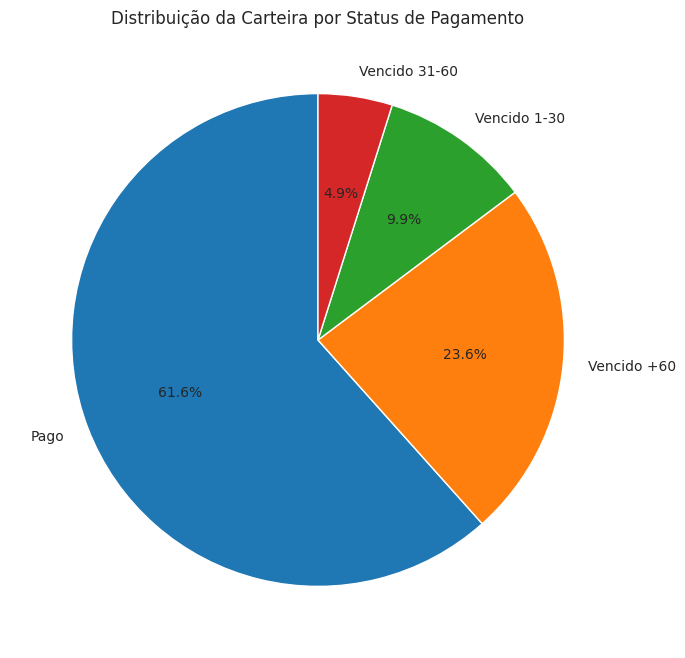

In [59]:
# Visualizar composição da carteira
plt.figure(figsize=(8,8))
plt.pie(aging_summary['valor_total'], labels=aging_summary['status'], autopct='%1.1f%%', startangle=90)
plt.title('Distribuição da Carteira por Status de Pagamento')
plt.show()

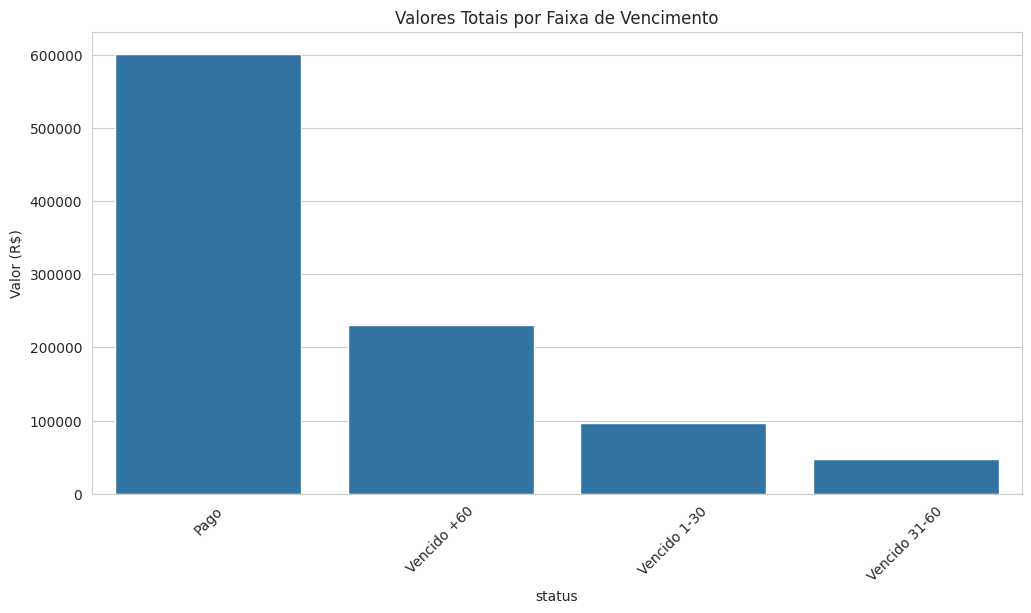

In [60]:
# Gráfico de barras com valores por faixa
sns.barplot(data=aging_summary, x='status', y='valor_total')
plt.title('Valores Totais por Faixa de Vencimento')
plt.xticks(rotation=45)
plt.ylabel('Valor (R$)')
plt.show()

### Clientes Inadimplentes

Identificamos clientes com faturas em atraso para priorizar ações de cobrança.

In [61]:
inadimplentes = aging.clientes_inadimplentes(transacoes, dias_minimo=1)
inadimplentes.sort_values('valor', ascending=False).head(10)

,id_cliente,valor,dias_atraso
13,16,37500,173
21,24,27000,126
19,22,19000,171
25,28,19000,149
43,46,18500,175
36,39,18000,157
30,33,15000,29
1,2,14000,178
8,10,13500,104
44,47,13500,162


## 4. Identificação de Pendências (Abatimentos, Créditos, Estornos)

O módulo `pendencies` processa os itens que precisam de ajuste manual e gera uma planilha para a equipe de backoffice.

In [64]:
pendencias_priorizadas = pendencies.identificar_pendencias(pendencias)
pendencias_priorizadas.head()

,id_pendencia,id_cliente,id_transacao,tipo,descricao,valor_original,valor_ajustado,prioridade
1,2,5,424,Abatimento,Duplicidade,1000,867.788337,Média
7,8,1,207,Abatimento,Valor divergente,500,469.821444,Média
9,10,30,197,Abatimento,Valor divergente,1000,845.490661,Média
11,12,2,196,Crédito,Valor divergente,500,428.601687,Média
12,13,12,378,Crédito,Duplicidade,1000,807.921082,Média


In [65]:
# Gerar planilha Excel com as pendências
pendencies.gerar_planilha_ajustes(pendencias_priorizadas, '../reports/pendencias_para_ajuste.xlsx')

Planilha gerada em ../reports/pendencias_para_ajuste.xlsx


## 5. Análise de Risco de Crédito

Calculamos indicadores financeiros a partir das demonstrações e combinamos com histórico de pagamentos para gerar um score de risco.

In [66]:
# Calcular indicadores financeiros
indicadores = risk_analysis.calcular_indicadores(demonstracoes)
indicadores.head()

,id_cliente,ano,ativo_circulante,passivo_circulante,ativo_total,passivo_total,receita_liquida,lucro_liquido,liquidez_corrente,endividamento,margem_liquida
0,1,2025,323837,797815,1947223,1457560,4353259,487754.121374,0.405905,0.748533,0.112043
1,2,2025,164983,267837,584863,721803,4950564,536940.141145,0.615983,1.234140,0.108460
2,3,2025,647852,196843,2624148,1670329,4272227,351808.987349,3.291212,0.636522,0.082348
3,4,2025,569872,531825,1861274,1476288,4780240,500204.317539,1.071540,0.793160,0.104640
4,5,2025,712302,784328,2568244,2162967,678859,36654.943793,0.908169,0.842197,0.053995


In [67]:
# Calcular score e classificação de risco
score_df = risk_analysis.calcular_score(clientes, transacoes, demonstracoes)
score_df.head()

,id_cliente,media_dias_atraso,liquidez_corrente,endividamento,dias_relacionamento,pontos,classificacao_risco
0,1,8.125000,0.405905,0.748533,1694,25,Alto
1,2,10.833333,0.615983,1.234140,1140,25,Alto
2,3,11.142857,3.291212,0.636522,1662,55,Médio
3,4,9.166667,1.071540,0.793160,1715,35,Médio-Alto
4,5,9.181818,0.908169,0.842197,343,15,Alto


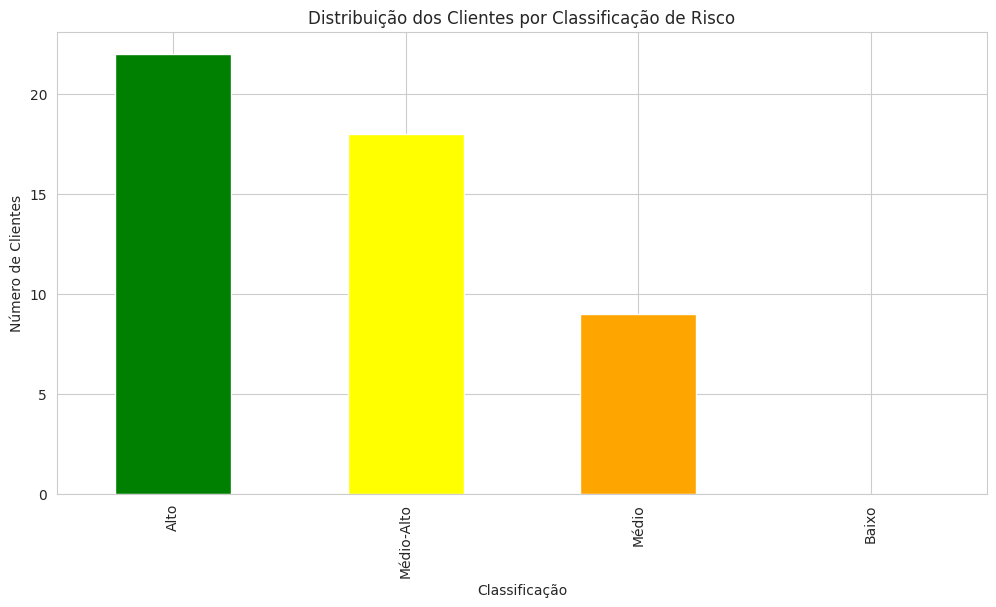

In [ ]:
# Distribuição das classificações de risco
score_df['classificacao_risco'].value_counts().plot(kind='bar', color=['green', 'yellow', 'orange', 'red'])
plt.title('Distribuição dos Clientes por Classificação de Risco')
plt.xlabel('Classificação')
plt.ylabel('Número de Clientes')
plt.show()

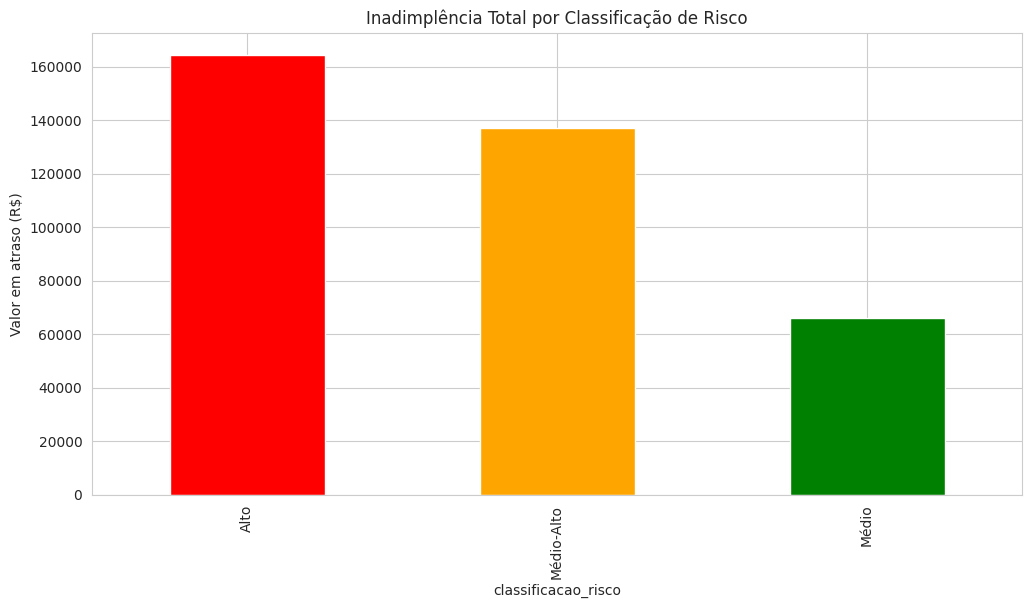

In [88]:
# Cruzar com dados de inadimplência
merged = inadimplentes.merge(score_df[['id_cliente', 'classificacao_risco']], on='id_cliente', how='left')
merged.groupby('classificacao_risco')['valor'].sum().plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Inadimplência Total por Classificação de Risco')
plt.ylabel('Valor em atraso (R$)')
plt.show()

## 6. Tratamento de Pedidos Bloqueados por Limite de Crédito

Analisamos os pedidos que excedem o limite de crédito e, com base no score do cliente, sugerimos ações.

In [84]:
pedidos_analise = blocked_orders.analisar_pedidos_bloqueados(pedidos, score_df)
pedidos_analise[['id_pedido', 'id_cliente', 'valor_pedido', 'excede_limite', 'classificacao_risco', 'acao_sugerida']].head(10)

,id_pedido,id_cliente,valor_pedido,excede_limite,classificacao_risco,acao_sugerida
0,3,22,17884,16884,Alto,Bloquear - risco alto
1,4,36,35616,17116,Médio,Liberar mediante análise rápida
2,5,29,12413,5413,Médio-Alto,Solicitar análise de crédito
3,6,22,10289,9289,Alto,Bloquear - risco alto
4,7,44,21337,23337,NaN,Bloquear - risco alto
5,8,8,43888,36388,Alto,Bloquear - risco alto
6,9,12,14909,7409,Alto,Bloquear - risco alto
7,12,6,42439,41439,Médio,Liberar mediante análise rápida
8,14,29,12418,5418,Médio-Alto,Solicitar análise de crédito
9,16,6,21708,20708,Médio,Liberar mediante análise rápida


In [89]:
# Gerar relatório para equipe de análise de crédito
blocked_orders.gerar_relatorio_pedidos(pedidos_analise, '../reports/pedidos_bloqueados_analise.xlsx')

Relatório salvo em ../reports/pedidos_bloqueados_analise.xlsx


## 7. Dashboard Interativo (Opcional)

O projeto inclui um dashboard desenvolvido com Dash, que pode ser executado separadamente. Aqui apenas mostramos alguns insights extras com gráficos estáticos.

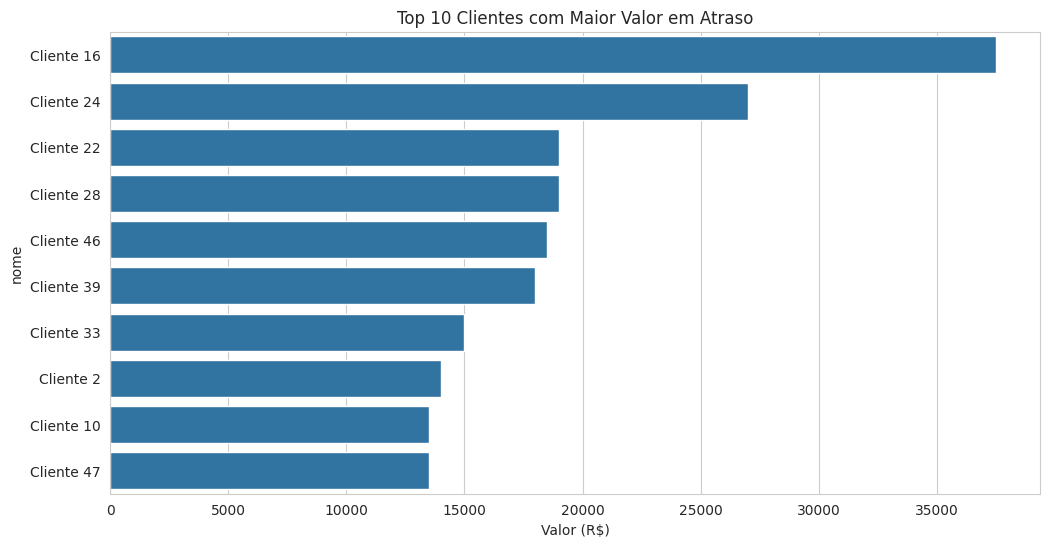

In [72]:
# Exemplo: Top 10 clientes com maior valor em atraso
top_inadimplentes = inadimplentes.merge(clientes[['id_cliente', 'nome']], on='id_cliente').sort_values('valor', ascending=False).head(10)
sns.barplot(data=top_inadimplentes, y='nome', x='valor')
plt.title('Top 10 Clientes com Maior Valor em Atraso')
plt.xlabel('Valor (R$)')
plt.show()

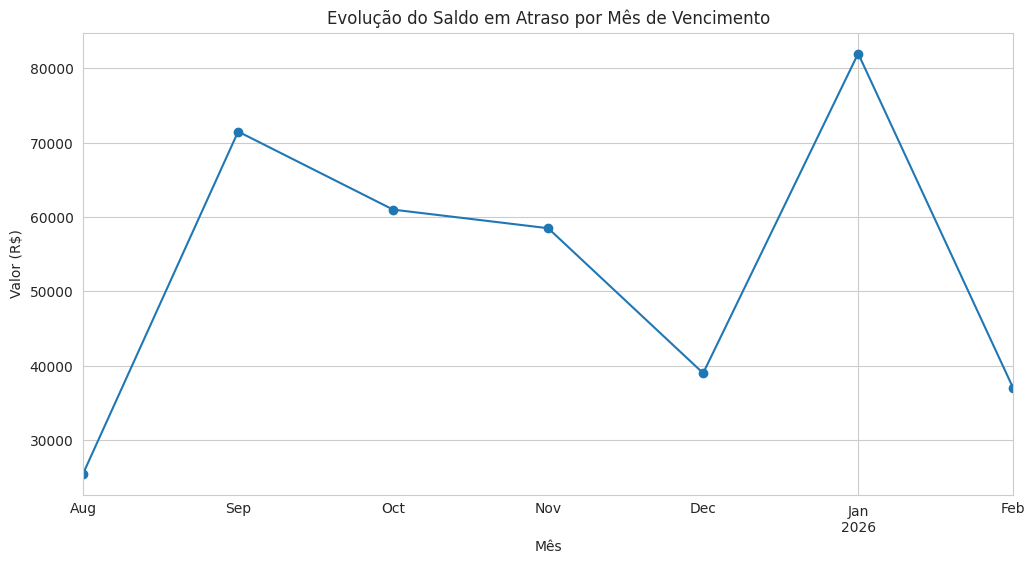

In [73]:
# Evolução do saldo em atraso ao longo do tempo (simulado com data de vencimento)
atrasados = transacoes[transacoes['status'] == 'Em aberto'].copy()
atrasados['mes_vencimento'] = pd.to_datetime(atrasados['data_vencimento']).dt.to_period('M')
atrasados.groupby('mes_vencimento')['valor'].sum().plot(marker='o')
plt.title('Evolução do Saldo em Atraso por Mês de Vencimento')
plt.ylabel('Valor (R$)')
plt.xlabel('Mês')
plt.show()

## 8. Conclusão

Este notebook demonstrou as principais funcionalidades do sistema de análise de crédito e cobrança desenvolvido em Python. As análises realizadas permitem:
- Acompanhar a situação da carteira de clientes.
- Identificar e priorizar ações de cobrança.
- Classificar clientes por risco de crédito.
- Auxiliar na decisão sobre pedidos bloqueados.
- Gerar relatórios para as equipes operacionais.

O sistema é modular e pode ser expandido com novas funcionalidades, como integração com fontes de dados reais, modelos preditivos mais avançados e alertas automáticos.